# 01 — Filter raw trajectory CSVs

Reads `{cell_id}_data{NN}.csv` from `raw/`, applies Butterworth `filtfilt` to position, velocity, and torque, computes acceleration from filtered velocity, writes cleaned CSVs to `filtered/`.

In [1]:
import sys, os, glob
ROOT = os.path.abspath(os.path.join(os.getcwd(), '..', '..'))
if ROOT not in sys.path: sys.path.insert(0, ROOT)
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from training_v2.data import filter_directory, filter_one_csv

In [2]:
RAW_DIR = '../../data'; OUT_DIR = '../filtered'
PATTERN = '*_data*.csv'
raw_files = sorted(glob.glob(os.path.join(RAW_DIR, PATTERN)))
print(f'Found {len(raw_files)} raw CSV files'); raw_files[:7]

Found 91 raw CSV files


['../../data/169_data02.csv',
 '../../data/169_data04.csv',
 '../../data/169_data08.csv',
 '../../data/169_data10.csv',
 '../../data/169_data13.csv',
 '../../data/169_data16.csv',
 '../../data/169_data22.csv']

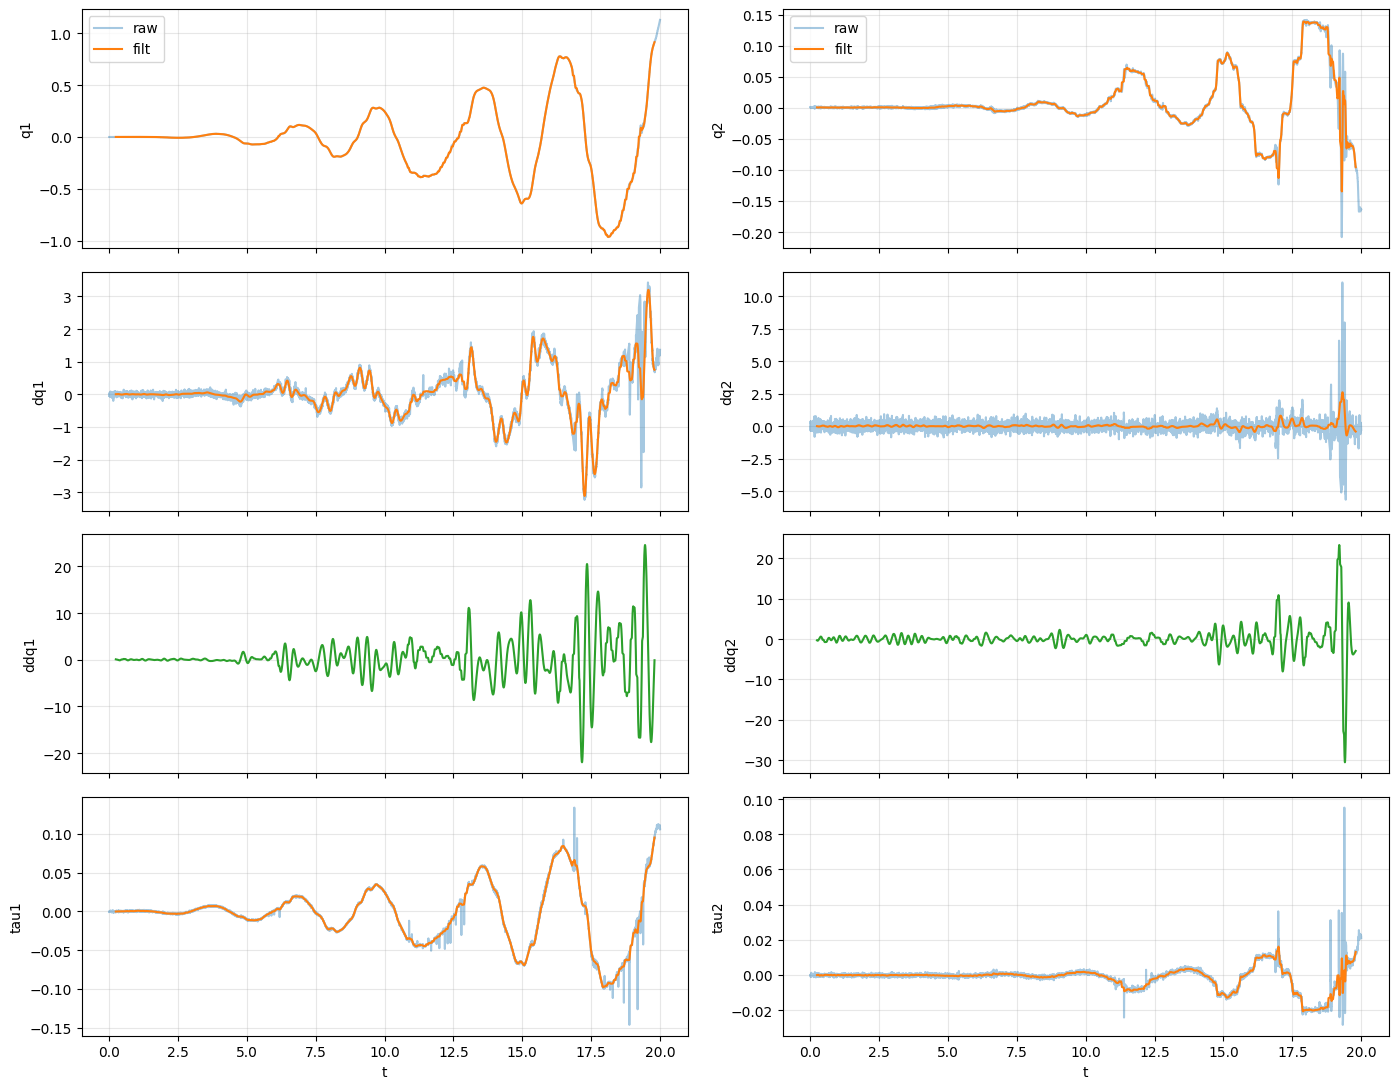

In [3]:
raw = pd.read_csv(raw_files[8])
f = filter_one_csv(raw_files[8], method='butterworth',
                   Wn_pos=0.05, Wn_vel=0.02, Wn_acc=0.02, Wn_tau=0.05, edge_trim=100)
# f = filter_one_csv(raw_files[1], method='butterworth',
#                    Wn_pos=0.05, Wn_vel=0.02, Wn_acc=0.02, Wn_tau=0.05, edge_trim=0)
# f = filter_one_csv(raw_files[4], method='savgol', savgol_poly=3, savgol_window=101, edge_trim=100)
fig, axes = plt.subplots(4, 2, figsize=(14, 11), sharex=True)
for j, n in enumerate(['1','2']):
    axes[0,j].plot(raw['time'], raw[f'pos_meas{n}'], alpha=.4, label='raw')
    axes[0,j].plot(f['time'], f[f'pos{n}'], lw=1.5, label='filt'); axes[0,j].legend(); axes[0,j].set_ylabel(f'q{n}')
    axes[1,j].plot(raw['time'], raw[f'vel_meas{n}'], alpha=.4); axes[1,j].plot(f['time'], f[f'vel{n}'], lw=1.5); axes[1,j].set_ylabel(f'dq{n}')
    axes[2,j].plot(f['time'], f[f'acc{n}'], color='C2'); axes[2,j].set_ylabel(f'ddq{n}')
    axes[3,j].plot(raw['time'], raw[f'tau_meas{n}'], alpha=.4); axes[3,j].plot(f['time'], f[f'tau{n}'], lw=1.5); axes[3,j].set_ylabel(f'tau{n}')
for ax in axes.flat: ax.grid(True, alpha=.3)
axes[3,0].set_xlabel('t'); axes[3,1].set_xlabel('t'); plt.tight_layout(); plt.show()


In [4]:
out = filter_directory(raw_dir=RAW_DIR, out_dir=OUT_DIR, pattern=PATTERN,
                       method='butterworth',
                       Wn_pos=0.05, Wn_vel=0.02, Wn_acc=0.02, Wn_tau=0.05,
                       edge_trim=100)

# out = filter_directory(raw_dir=RAW_DIR, out_dir=OUT_DIR, pattern=PATTERN,
#                        method='butterworth',
#                        Wn_pos=0.05, Wn_vel=0.02, Wn_acc=0.02, Wn_tau=0.05,
#                        edge_trim=0)

# out = filter_directory(raw_dir=RAW_DIR, out_dir=OUT_DIR, pattern=PATTERN,
#                        method='savgol', savgol_poly=3, savgol_window=101,
#                        edge_trim=100)
print(f'Wrote {len(out)} filtered CSVs')

  169_data02.csv                         9517 rows  -> ../filtered/169_data02.csv
  169_data04.csv                         9365 rows  -> ../filtered/169_data04.csv
  169_data08.csv                         9447 rows  -> ../filtered/169_data08.csv
  169_data10.csv                         9562 rows  -> ../filtered/169_data10.csv
  169_data13.csv                         9573 rows  -> ../filtered/169_data13.csv
  169_data16.csv                         9603 rows  -> ../filtered/169_data16.csv
  169_data22.csv                         9423 rows  -> ../filtered/169_data22.csv
  169_data27.csv                         9393 rows  -> ../filtered/169_data27.csv
  169_data29.csv                         8709 rows  -> ../filtered/169_data29.csv
  169_data34.csv                         9470 rows  -> ../filtered/169_data34.csv
  169_data37.csv                         9422 rows  -> ../filtered/169_data37.csv
  169_data38.csv                         9676 rows  -> ../filtered/169_data38.csv
  169_data44.csv

794215 total samples


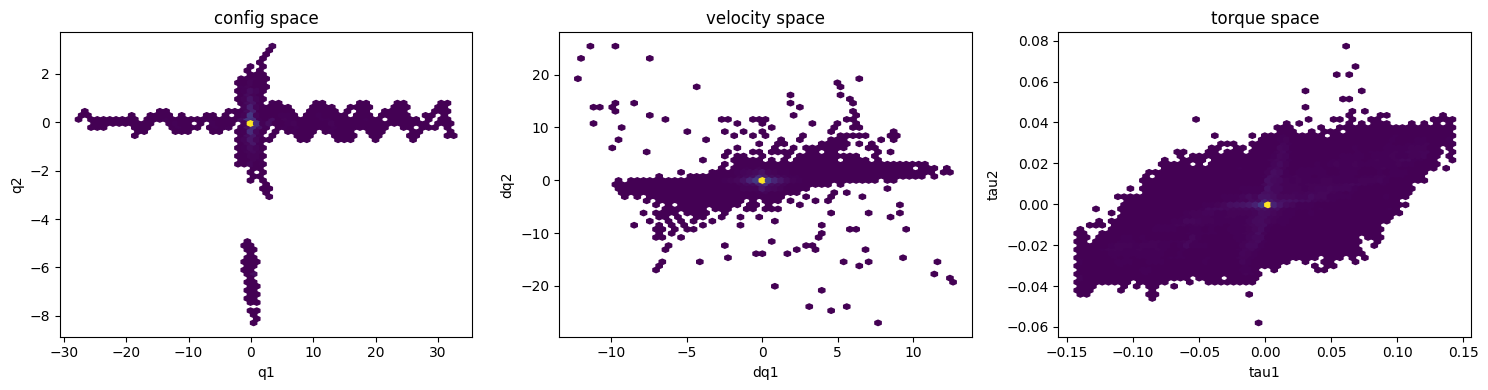

In [5]:
# Coverage check
all_q, all_qd, all_tau = [], [], []
for fp in sorted(glob.glob(os.path.join(OUT_DIR, PATTERN))):
    df = pd.read_csv(fp)
    all_q.append(df[['pos1','pos2']].to_numpy())
    all_qd.append(df[['vel1','vel2']].to_numpy())
    all_tau.append(df[['tau1','tau2']].to_numpy())
Q=np.concatenate(all_q); QD=np.concatenate(all_qd); TAU=np.concatenate(all_tau)
print(f'{len(Q)} total samples')
fig, ax = plt.subplots(1,3,figsize=(15,4))
ax[0].hexbin(Q[::10,0],Q[::10,1],gridsize=60,mincnt=1); ax[0].set_title('config space'); ax[0].set_xlabel('q1'); ax[0].set_ylabel('q2')
ax[1].hexbin(QD[::10,0],QD[::10,1],gridsize=60,mincnt=1); ax[1].set_title('velocity space'); ax[1].set_xlabel('dq1'); ax[1].set_ylabel('dq2')
ax[2].hexbin(TAU[::10,0],TAU[::10,1],gridsize=60,mincnt=1); ax[2].set_title('torque space'); ax[2].set_xlabel('tau1'); ax[2].set_ylabel('tau2')
plt.tight_layout(); plt.show()

In [6]:
import os, glob
import numpy as np
import pandas as pd

FILTERED_DIR = '../filtered'   # change if your dir is different
PATTERN = '*_data*.csv'

# Threshold: anything outside this is suspect.
# Real angles should stay within a few full rotations, say |q| <= 4*pi (~12.6 rad).
# Adjust if your data legitimately covers more.
Q_LIMIT_1 = 4
Q_LIMIT_2 = 4 
files = sorted(glob.glob(os.path.join(FILTERED_DIR, PATTERN)))
print(f'Scanning {len(files)} files for |q1| > {Q_LIMIT_1:.2f} or |q2| > {Q_LIMIT_2:.2f}\n')

hits = []
for fp in files:
    try:
        df = pd.read_csv(fp, usecols=['time', 'pos1', 'pos2'])
    except Exception as e:
        print(f'  {os.path.basename(fp)}: read error {e}')
        continue

    q1 = df['pos1'].to_numpy()
    q2 = df['pos2'].to_numpy()
    mask = (np.abs(q1) > Q_LIMIT_1) | (np.abs(q2) > Q_LIMIT_2)
    if mask.any():
        idx = np.where(mask)[0]
        first_t = df['time'].iloc[idx[0]]
        last_t  = df['time'].iloc[idx[-1]]
        hits.append({
            'file': os.path.basename(fp),
            'n_bad': int(mask.sum()),
            'q1_min': float(np.min(q1)), 'q1_max': float(np.max(q1)),
            'q2_min': float(np.min(q2)), 'q2_max': float(np.max(q2)),
            'first_bad_t': float(first_t),
            'last_bad_t':  float(last_t),
        })

print(f'Found {len(hits)} file(s) with out-of-range values:\n')
for h in hits:
    print(f"  {h['file']}")
    print(f"    bad samples:   {h['n_bad']}")
    print(f"    q1 range:      [{h['q1_min']:+.3f}, {h['q1_max']:+.3f}] rad")
    print(f"    q2 range:      [{h['q2_min']:+.3f}, {h['q2_max']:+.3f}] rad")
    print(f"    bad time span: {h['first_bad_t']:.2f}s -> {h['last_bad_t']:.2f}s")
    print()

Scanning 91 files for |q1| > 4.00 or |q2| > 4.00

Found 15 file(s) with out-of-range values:

  169_data34.csv
    bad samples:   49
    q1 range:      [-4.021, +0.229] rad
    q2 range:      [-0.204, +0.157] rad
    bad time span: 16.25s -> 16.34s

  169_data44.csv
    bad samples:   7653
    q1 range:      [-24.309, -0.000] rad
    q2 range:      [-0.241, +0.157] rad
    bad time span: 3.82s -> 19.80s

  169_data46.csv
    bad samples:   7846
    q1 range:      [-27.636, -0.001] rad
    q2 range:      [-0.538, +0.472] rad
    bad time span: 3.46s -> 19.80s

  169_data50.csv
    bad samples:   7757
    q1 range:      [+0.002, +24.079] rad
    q2 range:      [-0.459, +0.722] rad
    bad time span: 3.65s -> 19.80s

  169_data89.csv
    bad samples:   4761
    q1 range:      [-0.862, +0.610] rad
    q2 range:      [-7.398, -4.960] rad
    bad time span: 0.20s -> 9.80s

  16_data42.csv
    bad samples:   6823
    q1 range:      [-13.338, +0.000] rad
    q2 range:      [-0.282, +0.172] rad

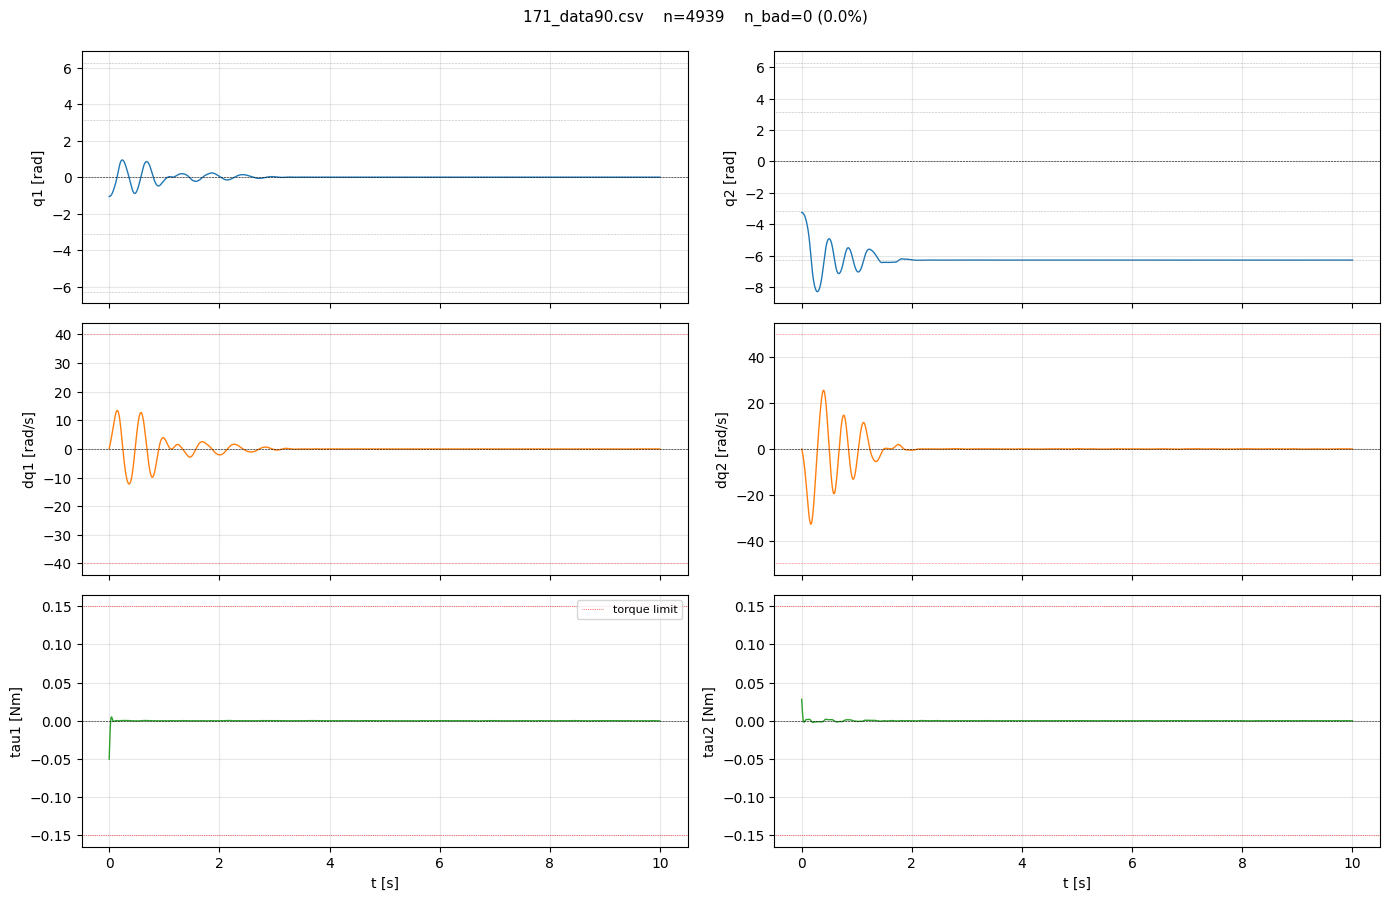


171_data90.csv:
  duration:    10.00s (4939 samples, dt~2.0ms)
  q1 range:    [ -1.061,  +0.945] rad
  q2 range:    [ -8.287,  -3.248] rad
  dq1 range:   [-12.226, +13.438] rad/s
  dq2 range:   [-32.837, +25.600] rad/s
  tau1 range:  [-0.0503, +0.0050] Nm
  tau2 range:  [-0.0022, +0.0281] Nm


In [11]:
from vis_csv import visualize_csv
visualize_csv('../filtered/171_data90.csv',q_limit=1000)

In [7]:
import numpy as np, pandas as pd, glob

# Stack all training states
train_states = []
for fp in glob.glob('training_v2/filtered/*.csv'):
    df = pd.read_csv(fp)
    train_states.append(df[['pos1','pos2','vel1','vel2']].to_numpy()[::5])  # subsample
train_states = np.vstack(train_states)
print(f'training states: {train_states.shape[0]}')

# For each test trajectory, find nearest-neighbor distance to training set
from scipy.spatial import cKDTree
tree = cKDTree(train_states)

for fp in sorted(glob.glob('training_v2/filtered_test/T*.csv')):
    df = pd.read_csv(fp)
    test_states = df[['pos1','pos2','vel1','vel2']].to_numpy()[::10]
    d, _ = tree.query(test_states, k=1)
    print(f'{fp.split("/")[-1]:25s}  median nn-dist={np.median(d):.3f}'
          f'  90%={np.percentile(d, 90):.3f}  max={d.max():.3f}')

ValueError: need at least one array to concatenate